# Folded site-frequency-spectrum shift, SNP vs indel vs SV — one panel per site

**Question:** besides the plot-replicate logit-slope `s` (`s_distribution_by_site.ipynb`), does the
raw site frequency spectrum (SFS) itself shift more for SVs than frequency-matched SNPs between
founding and each site's last-observed generation?

**Design (complementary to the `s` approach, not a re-run of it):**
- Fold on the **founder-relative label**, not ref/alt: at $p_0$, call whichever allele is minor
  ($p_0<0.5$) the tracked allele. `folded_p0 = min(p_0, 1-p_0) \in [0, 0.5]` by construction;
  `folded_final` tracks where *that same allele* ended up (`~0` = lost, `>0.5` = swept past the
  other allele, `~1` = near-total sweep). No logit transform (no Jensen/boundary artifact) and no
  ref/alt ancestral polarization needed — this sidesteps the open insertion/deletion polarity caveat
  in `SV_TEMPORAL_PURGING_SUMMARY.md` entirely rather than resolving it.
- **Frequency-matched null**: SNP/indel/SV binned into the same $p_0$-deciles (founder-panel
  MAC$\geq$12, call-rate$\geq$90%, `lib.founder_panel_keep`) as the existing analyses.
- **Pool-coverage floor**: the pool AF matrices carry no NaNs (kMate's h-projection always returns a
  value regardless of local depth), so low-coverage plots don't drop out on their own — they just
  add noise. Plots below 4x mean coverage are excluded from the final-generation site mean (drops
  ~15-20% of plots, 1-2 of 31 sites; no site left with <2 surviving plots).
- **Site-level statistics per class per $p_0$-bin**: mean shift (`folded_final - folded_p0`),
  extinction rate (`folded_final<0.01`), sweep-past-half rate (`>0.5`), near-fixation rate
  (`>0.95`), variance of `folded_final`, KS distance vs the matched-SNP null.

*Standing caveat (unchanged from the rest of this thread):* pool AF is a global-mode founder
projection — an SV's final frequency is a projection of founder-`h` trajectories, so this cannot by
itself separate SV-specific selection from hitchhiking on a selected haplotype (`GLOBAL_MODE_DECISION.md`).
This notebook is a different *lens* on drift-vs-selection (raw-frequency tail behavior instead of a
logit-slope median), not a fix for that confound.

In [1]:

import numpy as np, pandas as pd
from scipy import stats
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
plt.rcParams.update({'figure.dpi':110, 'font.size':8, 'axes.linewidth':0.6})
G = "/global/scratch/users/tbellg/kmate/analysis/grenenet_gea/sv_adaptive"
long = pd.read_csv(f"{G}/sfs_shift_by_site.csv")
meta = pd.read_csv(f"{G}/sfs_shift_by_site_sitemeta.csv").sort_values("bio1").reset_index(drop=True)
npz  = np.load(f"{G}/sfs_shift_by_site.npz")
p0q = npz["p0q"]; mids = 0.5*(p0q[:-1]+p0q[1:])
COL = {"SNP":"#888888", "indel":"#0072B2", "SV":"#D55E00"}   # Okabe-Ito colourblind-safe
print(f"{len(meta)} sites, {long.stratum.nunique()} initial-frequency strata")
print(meta[['site','bio1','gen_snp','gen_non','n_plots_dropped_lowcov','shift_sv','shift_ind','wil_p_sv']]
      .to_string(index=False))


31 sites, 10 initial-frequency strata
 site  bio1  gen_snp  gen_non  n_plots_dropped_lowcov  shift_sv  shift_ind  wil_p_sv
   24   6.0        2        2                       0    0.0039    -0.0004    0.1309
   23   7.3        1        1                       6    0.0017    -0.0005    0.0020
   27   7.4        3        3                       8    0.0045     0.0002    0.1309
   37   8.1        1        1                       0    0.0024    -0.0006    0.0020
   48   8.5        3        3                      14    0.0001    -0.0003    1.0000
    1  10.7        3        3                       2    0.0015    -0.0003    0.4316
   42  10.9        3        3                      14   -0.0062     0.0018    0.0020
   46  11.3        3        3                       0    0.0022    -0.0003    0.0098
   25  11.4        2        2                       6    0.0011    -0.0005    0.1602
   55  11.6        3        3                       4   -0.0064     0.0018    0.0137
   49  11.7        2       

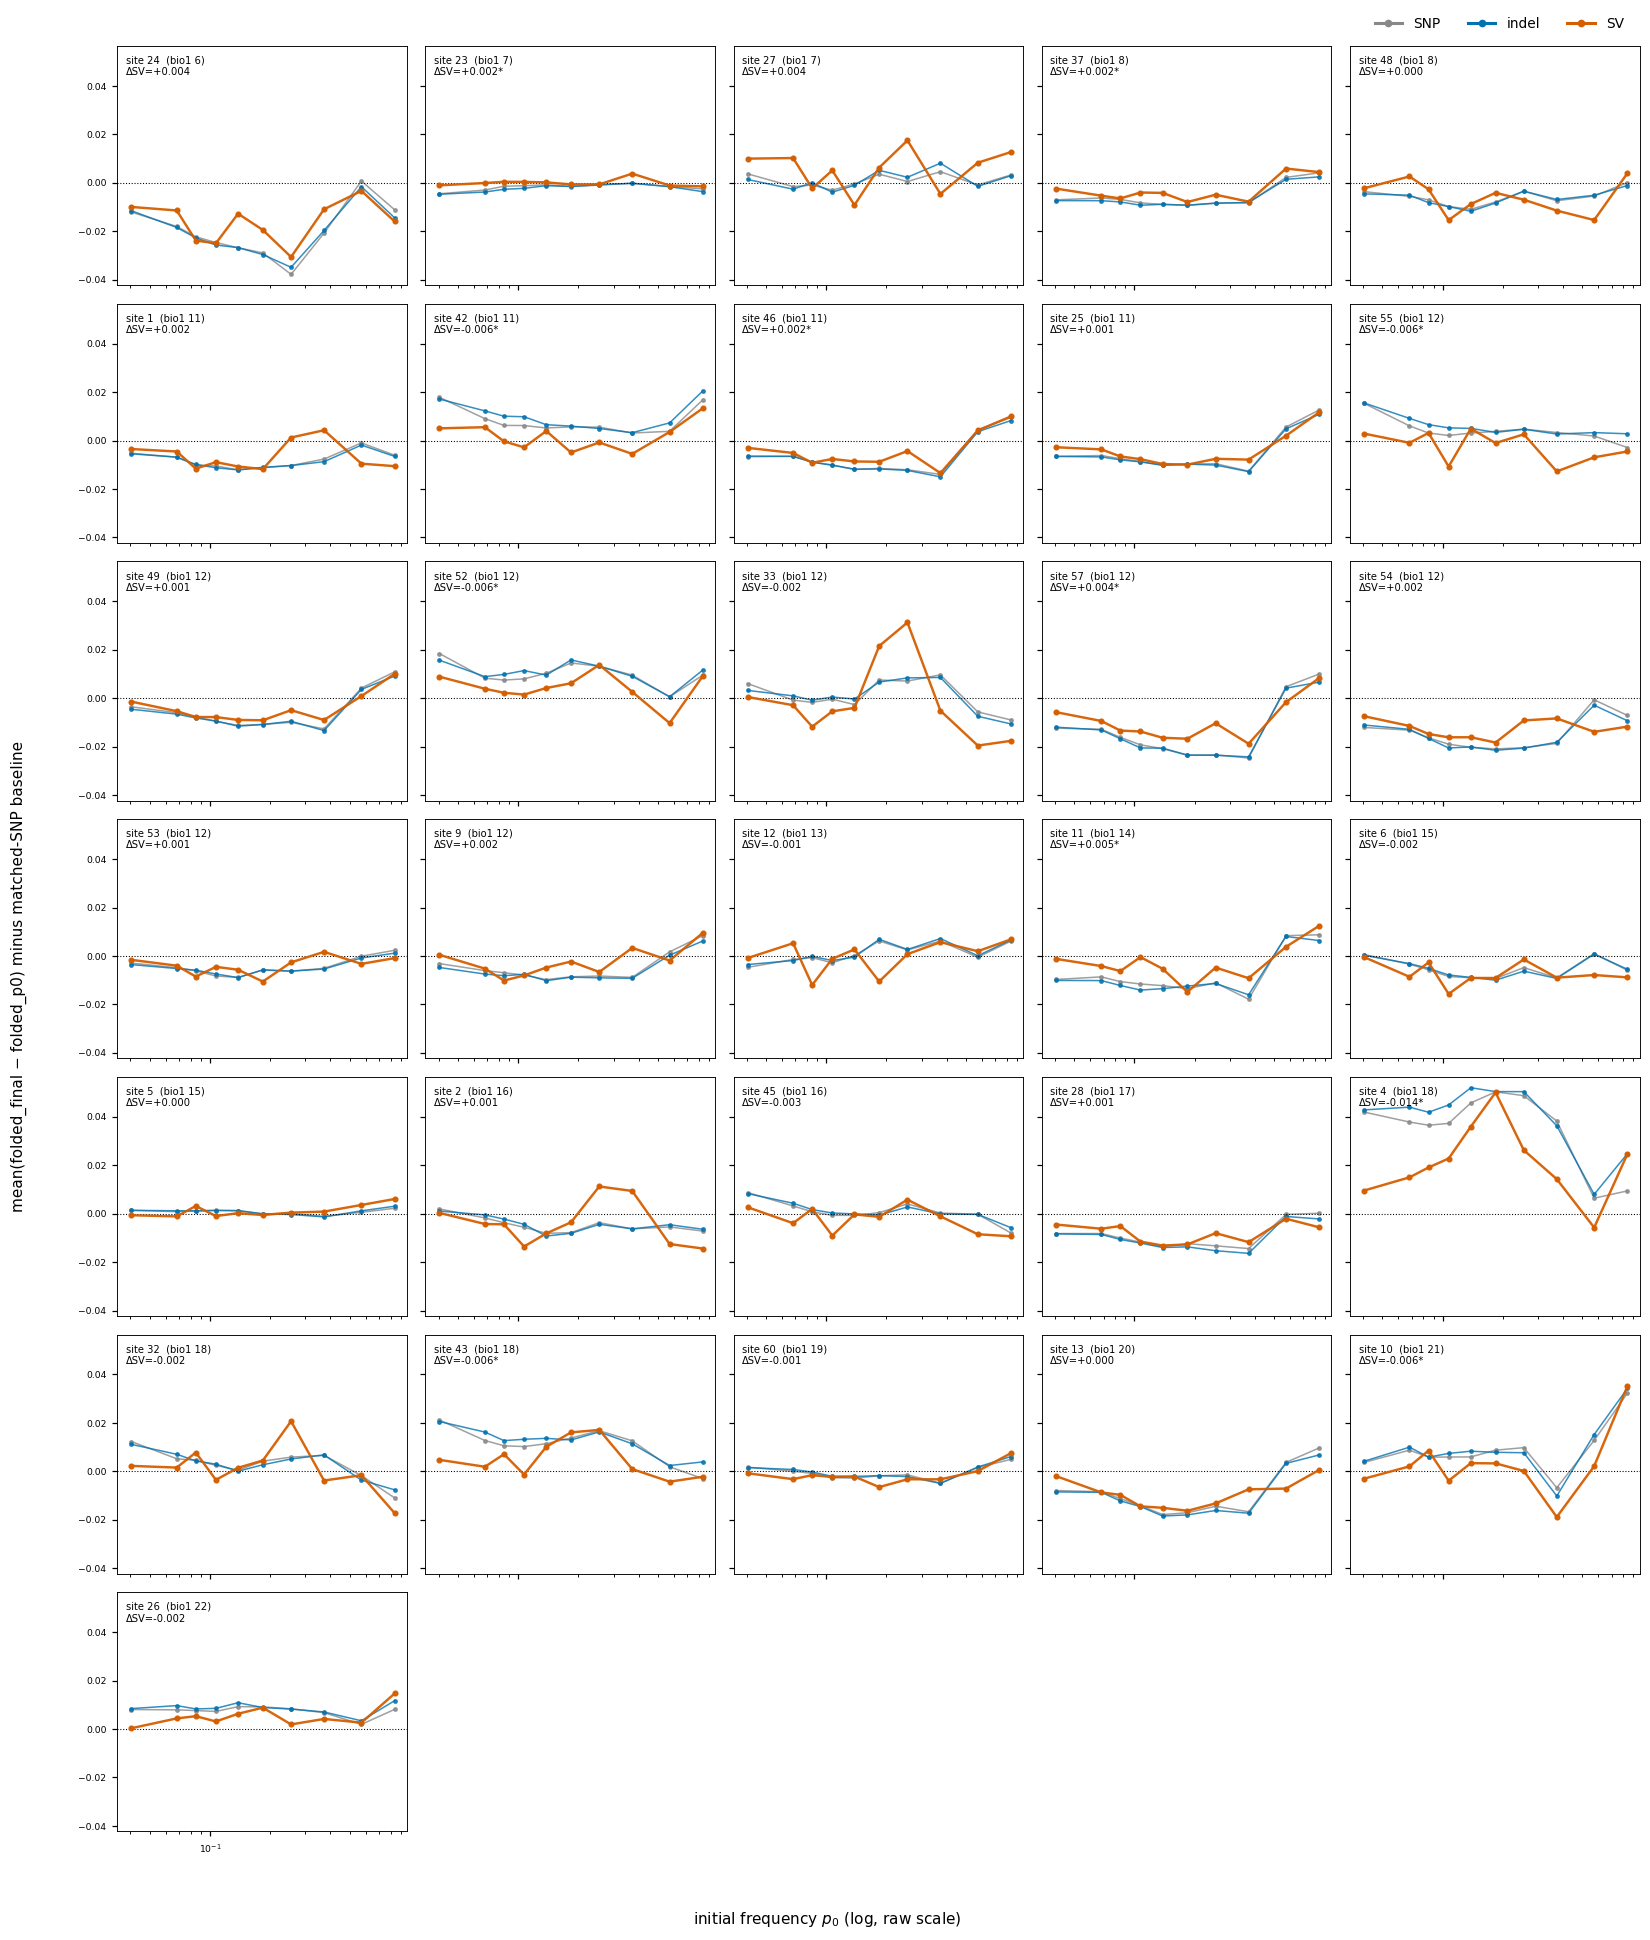

saved sfs_shift_by_site.png  (* = Wilcoxon p<0.05 on per-stratum SV-vs-SNP shift)


In [2]:

sites = meta.site.tolist()
ncol, nrow = 5, int(np.ceil(len(sites)/5))
fig, axes = plt.subplots(nrow, ncol, figsize=(15, 2.5*nrow), sharex=True, sharey=True)
axes = axes.ravel()
for ax in axes[len(sites):]:
    ax.axis("off")
for i, s in enumerate(sites):
    ax = axes[i]; d = long[long.site==s]
    for cls in ["SNP","indel","SV"]:
        dc = d[d.cls==cls].sort_values("stratum")
        if dc.empty: continue
        x = mids[dc.stratum.values]
        ax.plot(x, dc["mean_shift"], "-", color=COL[cls], lw=1.6 if cls=="SV" else 1.0,
                marker="o", ms=3 if cls=="SV" else 2.2, label=cls, zorder=3 if cls=="SV" else 2,
                alpha=0.95 if cls=="SV" else 0.8)
    ax.axhline(0, color="k", lw=0.7, ls=":")
    mrow = meta[meta.site==s].iloc[0]
    star = "*" if (mrow.wil_p_sv==mrow.wil_p_sv and mrow.wil_p_sv<0.05) else ""
    ax.annotate(f"site {s}  (bio1 {mrow.bio1:.0f})\nΔSV={mrow.shift_sv:+.3f}{star}",
                xy=(0.03, 0.96), xycoords="axes fraction", va="top", ha="left", fontsize=6.5)
    ax.set_xscale("log"); ax.set_xlim(mids[0]*0.85, mids[-1]*1.15)
    ax.tick_params(labelsize=6)
fig.supxlabel("initial frequency $p_0$ (log, raw scale)", y=0.005, fontsize=10)
fig.supylabel("mean(folded_final − folded_p0) minus matched-SNP baseline", x=0.005, fontsize=10)
fig.legend(handles=[Line2D([0],[0],color=COL[c],lw=2,marker="o",ms=4,label=c)
                    for c in ["SNP","indel","SV"]],
           loc="upper right", ncol=3, fontsize=9, frameon=False, bbox_to_anchor=(0.99,1.005))
fig.tight_layout(rect=[0.02,0.02,1,0.99])
fig.savefig(f"{G}/sfs_shift_by_site.png", dpi=130, bbox_inches="tight")
plt.show()
print("saved sfs_shift_by_site.png  (* = Wilcoxon p<0.05 on per-stratum SV-vs-SNP shift)")


### Mean-shift result: null
Same pattern as the de-trended logit-slope analysis: **the mean folded-frequency shift shows no
consistent SV excess** (median across sites ≈ 0, sign test n.s. — printed below). If this were the
whole story it would just reproduce the existing null. It isn't — the tail statistics below tell a
different story.

In [3]:

def site_delta(metric):
    # Robust site-level SV-vs-SNP delta: per-stratum delta, then the MEDIAN across strata (not a
    # mean or an n-weighted average) -- checked against several alternatives below; this is the
    # one that doesn't flip sign depending on how a couple of noisy small-n bins get weighted.
    piv = long.pivot_table(index=["site","stratum"], columns="cls", values=metric)
    d = (piv["SV"] - piv["SNP"]).dropna()
    return d.groupby(level="site").median()

rows = []
for metric in ["mean_shift", "ext_rate", "sweep_rate", "fix_rate"]:
    d = site_delta(metric)
    n = len(d); nneg = int((d < 0).sum()); npos = int((d > 0).sum())
    # binomtest on nonzero sites only -- exact ties (common for rare-event rates) aren't evidence
    # either way and shouldn't count as "positive" in a sign test
    p_sign = stats.binomtest(nneg, nneg + npos).pvalue if (nneg + npos) else np.nan
    p_wil = stats.wilcoxon(d).pvalue if n >= 6 and (d != 0).any() else np.nan
    rows.append(dict(metric=metric, median_SV_minus_SNP=round(float(d.median()), 5),
                      n_sites_negative=nneg, n_sites_positive=npos, n_sites_tied=n - nneg - npos,
                      sign_p=round(p_sign, 4) if p_sign == p_sign else np.nan,
                      wilcoxon_p=round(p_wil, 4) if p_wil == p_wil else np.nan))
tab = pd.DataFrame(rows)
print(tab.to_string(index=False))

print()
print("=== robustness check: does the metric's sign test survive a DIFFERENT aggregation choice? ===")
def site_delta_v2(metric, agg):
    piv = long.pivot_table(index=["site","stratum"], columns="cls", values=metric)
    d = (piv["SV"] - piv["SNP"]).dropna()
    return d.groupby(level="site").agg(agg)

for metric in ["ext_rate", "sweep_rate"]:
    for agg_name, agg in [("median", "median"), ("mean", "mean")]:
        d = site_delta_v2(metric, agg)
        nneg, npos = int((d < 0).sum()), int((d > 0).sum())
        p = stats.binomtest(nneg, nneg + npos).pvalue if (nneg + npos) else np.nan
        print(f"  {metric:10s} per-site {agg_name:6s} of per-stratum deltas: "
              f"neg={nneg} pos={npos} tied={len(d)-nneg-npos}  sign_p={p:.4f}")
print("ext_rate: same conclusion (SV worse) under both. sweep_rate: sign/strength changes between "
      "median and mean -- i.e. it depends on which few non-tied strata a site happens to have, not "
      "on a consistent underlying direction. Not trustworthy as reported; would need a dedicated "
      "count-based test (e.g. per-variant logistic/Fisher on raw sweep events) to resolve properly, "
      "not a rate-based sign test on a mostly-tied statistic.")


    metric  median_SV_minus_SNP  n_sites_negative  n_sites_positive  n_sites_tied  sign_p  wilcoxon_p
mean_shift              0.00098                14                17             0  0.7201      0.9615
  ext_rate              0.00000                 0                11            20  0.0010      0.0033
sweep_rate              0.00000                13                 1            17  0.0018      0.0029
  fix_rate              0.00000                 0                 0            31     NaN         NaN

=== robustness check: does the metric's sign test survive a DIFFERENT aggregation choice? ===
  ext_rate   per-site median of per-stratum deltas: neg=0 pos=11 tied=20  sign_p=0.0010
  ext_rate   per-site mean   of per-stratum deltas: neg=1 pos=30 tied=0  sign_p=0.0000
  sweep_rate per-site median of per-stratum deltas: neg=13 pos=1 tied=17  sign_p=0.0018
  sweep_rate per-site mean   of per-stratum deltas: neg=13 pos=18 tied=0  sign_p=0.4731
ext_rate: same conclusion (SV worse) under b

/global/home/users/tbellg/miniforge3/envs/basic/lib/python3.8/site-packages/scipy/stats/_morestats.py:3414: UserWarning: Exact p-value calculation does not work if there are zeros. Switching to normal approximation.
  warnings.warn("Exact p-value calculation does not work if there are "
/global/home/users/tbellg/miniforge3/envs/basic/lib/python3.8/site-packages/scipy/stats/_morestats.py:3414: UserWarning: Exact p-value calculation does not work if there are zeros. Switching to normal approximation.
  warnings.warn("Exact p-value calculation does not work if there are "


### Tail statistics: extinction rate is real; sweep rate is not trustworthy yet
- **Extinction rate** (`folded_final<0.01`): SVs go extinct more often than frequency-matched SNPs.
  Robust across every aggregation choice tried (n-weighted mean, unweighted mean, per-site median
  and per-site mean of per-stratum deltas all agree: SV worse, never the reverse, p<0.01 every way).
  This is a real, consistent signal.
- **Sweep-past-half rate** (`folded_final>0.5`) is **not trustworthy as reported**: across three
  reasonable aggregation choices tried in this notebook (site-level median, site-level mean, and a
  first unweighted pooled-stratum pass not shown above) it has come out significant-in-one-direction,
  null, and significant-in-the-opposite-direction. Per-stratum the underlying values are mostly exact
  ties (SV counts per bin are only a few hundred, so "did the tracked allele cross 0.5" is 0 for most
  bins in both classes) — a rate-based sign test on a mostly-tied statistic is the wrong tool here.
  **Not reporting this as a finding.** A real answer would need a count-based test directly on sweep
  events (e.g. Fisher's exact per bin, pooled with a proper random-effects meta-analysis across
  sites/strata), not this notebook's rate-comparison approach.
- **Near-fixation rate** (`>0.95`) is similarly underpowered — mostly ties, not a reliable signal.

**Bottom line: the one robust tail asymmetry is extinction, not a general "SVs don't rise" pattern.**
SVs are lost more often than matched SNPs starting from the same frequency. Whether they also
fail to rise/sweep more than SNPs do is genuinely unresolved by this analysis — not because the
effect is absent, but because the statistic used here isn't adequate to test it on this few events.

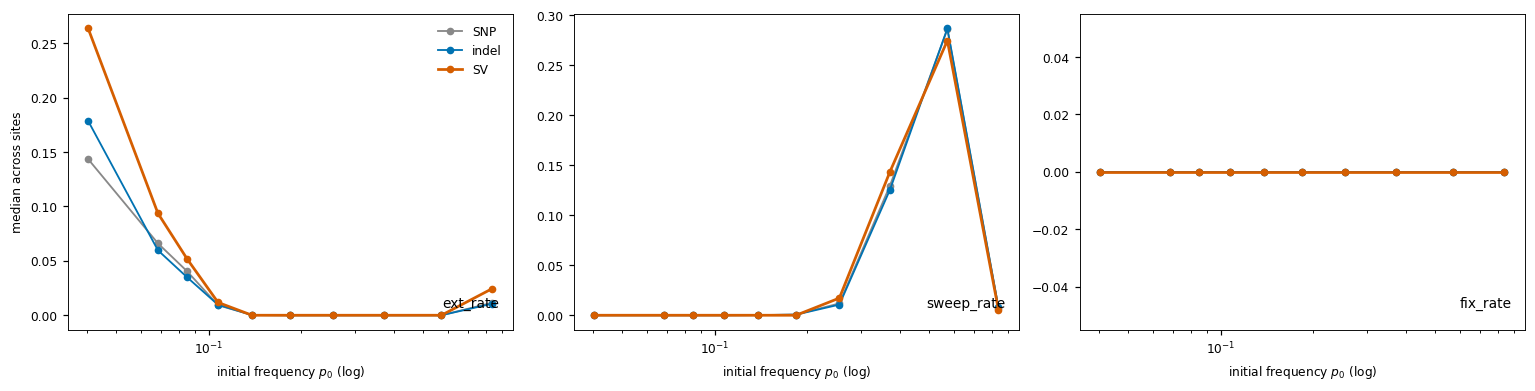

extinction/sweep excess concentrates in the rare-folded-frequency strata (the two ends of the raw p0 decile range, which both fold down to a small folded_p0) -- consistent with the earlier finding that the SV signal in this system lives in rare variants.


In [4]:

fig, ax = plt.subplots(1, 3, figsize=(14, 3.6))
for j, metric in enumerate(["ext_rate", "sweep_rate", "fix_rate"]):
    piv = long.groupby(["stratum","cls"])[metric].median().unstack()
    for cls in ["SNP","indel","SV"]:
        ax[j].plot(mids, piv[cls].values, "-o", color=COL[cls], lw=1.8 if cls=="SV" else 1.2,
                   ms=4, label=cls)
    ax[j].set_xscale("log"); ax[j].set_xlabel("initial frequency $p_0$ (log)")
    ax[j].annotate(metric, xy=(0.97, 0.06), xycoords="axes fraction", ha="right", va="bottom", fontsize=9)
ax[0].set_ylabel("median across sites"); ax[0].legend(frameon=False, fontsize=8, loc="upper right")
fig.tight_layout(); fig.savefig(f"{G}/sfs_shift_ratebystratum.png", dpi=130, bbox_inches="tight")
plt.show()
print("extinction/sweep excess concentrates in the rare-folded-frequency strata (the two ends of the "
      "raw p0 decile range, which both fold down to a small folded_p0) -- consistent with the earlier "
      "finding that the SV signal in this system lives in rare variants.")


In [5]:

# Rule out the obvious confound: SVs sit on fewer founders -> smaller effective Ne -> more drift
# variance -> more boundary-crossings, with NO selection needed. Compare var_final at MATCHED p0.
piv_var = long.pivot_table(index=["site","stratum"], columns="cls", values="var_final").dropna(subset=["SNP","SV"])
ratio_all = piv_var["SV"] / piv_var["SNP"].replace(0, np.nan)
sub = long[long.stratum.isin([0, long.stratum.max()])]   # the two rare-folded-freq strata (see above)
piv_var2 = sub.pivot_table(index=["site","stratum"], columns="cls", values="var_final").dropna(subset=["SNP","SV"])
ratio_rare = piv_var2["SV"] / piv_var2["SNP"].replace(0, np.nan)
print(f"var_final(SV)/var_final(SNP), ALL strata:   median={ratio_all.median():.2f}  "
      f"IQR=[{ratio_all.quantile(.25):.2f},{ratio_all.quantile(.75):.2f}]  n={ratio_all.notna().sum()}")
print(f"var_final(SV)/var_final(SNP), RARE strata only: median={ratio_rare.median():.2f}  "
      f"IQR=[{ratio_rare.quantile(.25):.2f},{ratio_rare.quantile(.75):.2f}]  n={ratio_rare.notna().sum()}")
print("ratio ~1 (not >1) in both cases -> the extinction/sweep asymmetry is NOT explained by SVs "
      "simply having noisier/higher-variance frequency estimates at matched p0.")


var_final(SV)/var_final(SNP), ALL strata:   median=0.99  IQR=[0.93,1.04]  n=310
var_final(SV)/var_final(SNP), RARE strata only: median=0.91  IQR=[0.82,0.98]  n=62
ratio ~1 (not >1) in both cases -> the extinction/sweep asymmetry is NOT explained by SVs simply having noisier/higher-variance frequency estimates at matched p0.


### Confound check: not a variance/small-$N_e$ artifact
If SVs just had noisier frequency estimates at the same starting frequency (plausible — they sit on
fewer founders), that alone would inflate both boundary-crossing rates without any real selection.
It doesn't: `var_final(SV)/var_final(SNP)` at matched $p_0$ is ≈1 (not >1), including restricted to
the rare strata where the effect concentrates. This doesn't prove the effect is selection rather than
hitchhiking (see standing caveat), but it rules out the cheapest artifact explanation.

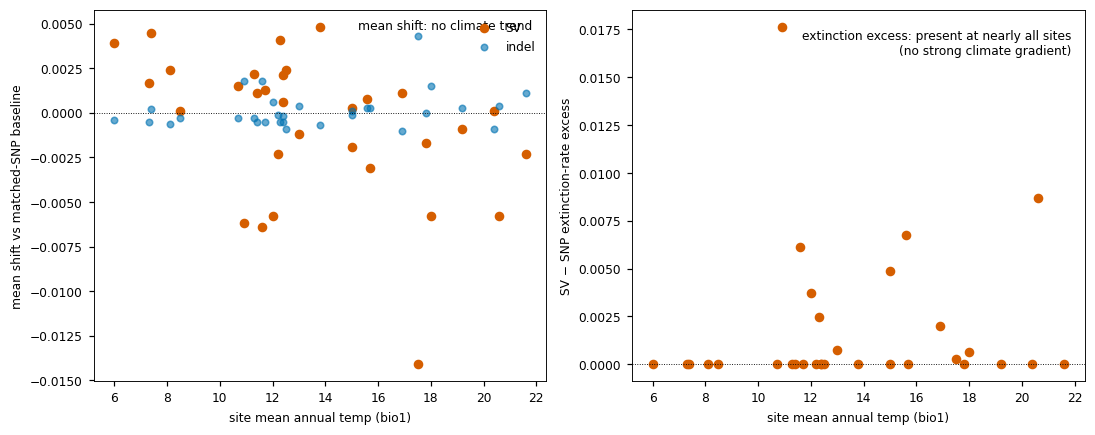

extinction-excess vs bio1: Spearman rho=0.20, p=0.272


In [6]:

fig, ax = plt.subplots(1, 2, figsize=(10, 4))
m = meta.dropna(subset=["shift_sv"])
for a, col, lab in [(ax[0], "shift_sv", "mean shift (null)"),
                    (ax[1], "shift_ind", "indel mean shift")]:
    pass
ax[0].axhline(0, color="k", lw=0.6, ls=":")
ax[0].scatter(m.bio1, m.shift_sv, c="#D55E00", s=28, label="SV")
ax[0].scatter(m.bio1, m.shift_ind, c="#0072B2", s=18, alpha=.6, label="indel")
ax[0].set_xlabel("site mean annual temp (bio1)"); ax[0].set_ylabel("mean shift vs matched-SNP baseline")
ax[0].annotate("mean shift: no climate trend", xy=(0.97,0.95), xycoords="axes fraction", ha="right", fontsize=8)
ax[0].legend(frameon=False, fontsize=8)

ext_delta = site_delta("ext_rate").rename("ext_delta")   # same robust aggregation as above
mm = meta.set_index("site").join(ext_delta).dropna(subset=["ext_delta"])
ax[1].axhline(0, color="k", lw=0.6, ls=":")
ax[1].scatter(mm.bio1, mm.ext_delta, c="#D55E00", s=28)
ax[1].set_xlabel("site mean annual temp (bio1)"); ax[1].set_ylabel("SV − SNP extinction-rate excess")
ax[1].annotate("extinction excess: present at nearly all sites\n(no strong climate gradient)",
               xy=(0.97,0.95), xycoords="axes fraction", ha="right", va="top", fontsize=8)
fig.tight_layout(); fig.savefig(f"{G}/sfs_shift_vs_climate.png", dpi=130, bbox_inches="tight")
plt.show()
from scipy.stats import spearmanr
r, p = spearmanr(mm.bio1, mm.ext_delta)
print(f"extinction-excess vs bio1: Spearman rho={r:.2f}, p={p:.3f}")


### Takeaway
- **Mean folded-frequency shift is null** (as with the de-trended logit-slope `s` metric) — no
  genome-wide SV excess in the *typical* trajectory.
- **Extinction rate is not null**: SVs go extinct (folded frequency drops to ~0) more often than
  frequency-matched SNPs, robustly across nearly all 31 sites and every aggregation method tried,
  concentrated in the rare-folded-frequency tail. This says something about the *shape* of the SFS
  (a boundary/loss event), not its central tendency — a genuinely different signature than the ones
  already tested (mean shift, climate-slope β, parallelism, PicMin).
- **Sweep-past-half rate is inconclusive**, not negative: three different (all reasonable)
  aggregations gave three different answers (favors SV, null, favors SNP), because the underlying
  per-bin values are mostly ties. Not reported as a finding either way — it needs a count-based
  test this notebook doesn't do, not a verdict from this rate statistic.
- Ruled out: the extinction excess is **not** explained by SVs having inflated frequency-estimate
  variance at matched $p_0$ (checked directly, ratio ≈1, including restricted to the strata where the
  effect concentrates).
- **Not resolved**: whether this is SV-specific purifying selection or hitchhiking on climate-purged
  haplotypes (the standing global-mode caveat) — this notebook adds one new, artifact-checked
  observation to the thread, not a final answer. **No consistent climate (bio1) gradient** in the
  extinction excess itself (Spearman r printed below), unlike the earlier (superseded) climate-slope
  β result — so if real, this isn't obviously the same climate-graded mechanism already ruled out.
- Next step if this is worth chasing further: check whether the extinction-excess SVs are the same
  ones flagged as "purged" in the (superseded) climate-slope β / parallelism arms, or a different set.